# 📊 Bilan Final : Évaluation du Pipeline Hiérarchique

Ce notebook représente l'aboutissement de l'architecture Zoidberg (Version Keras).
Nous allons utiliser notre **Pipeline Hiérarchique** qui se compose de deux experts :
1. **Modèle Binaire (Stage 1)** : Détecte si le patient est Sain (Normal) ou Malade (Pneumonie).
2. **Modèle Subtype (Stage 2)** : Si le patient est malade, ce modèle spécialisé détermine s'il s'agit d'une pneumonie **Virale** ou **Bactérienne**.

Nous allons évaluer les performances globales puis utiliser l'**Explicabilité (Grad-CAM)** pour comprendre les décisions du modèle.

In [ ]:
import os
import pathlib
import numpy as np
import matplotlib.pyplot as plt

# Imports des modules Zoidberg
import sys
sys.path.append('..') # Pour pouvoir importer 'src'

from src.models.evaluate_hierarchical import evaluate_hierarchical_model
from src.models.hierarchical_pipeline import HierarchicalClassifier
from src.visualization.grad_cam import make_gradcam_heatmap, display_gradcam, find_last_conv_layer, get_img_array
from tensorflow.keras.applications.efficientnet import preprocess_input

## 1. Évaluation Quantitative sur le Jeu de Test
Nous allons faire passer l'ensemble des images de test dans notre pipeline à deux étages. 
Le script va générer le rapport de classification (Précision, Rappel) et la **Matrice de Confusion**.

In [ ]:
# Lancement de l'évaluation globale (Matrice de confusion incluse)
# Attention, cette cellule peut prendre quelques minutes selon votre machine.
evaluate_hierarchical_model("models/trained/efficientnet_binary_stage1.keras", "models/trained/efficientnet_subtype_binary.keras")

⏳ Chargement des modèles hiérarchiques...
❌ Erreur lors du chargement des modèles. Vérifie les chemins : File not found: filepath=models/trained/efficientnet_binary_stage1.keras. Please ensure the file is an accessible `.keras` zip file.


## 2. Évaluation Qualitative : Explainable AI (Grad-CAM)
Maintenant que nous connaissons nos scores, nous devons **vérifier cliniquement** notre modèle. 
Est-ce qu'il regarde bien les poumons pour différencier Virus et Bactérie, ou est-ce qu'il triche (Shortcut Learning) ?

In [9]:
# Initialisation de notre classifieur pour récupérer les modèles
classifier = HierarchicalClassifier(
    binary_model_path="../models/trained/efficientnet_binary_stage1.keras",
    subtype_model_path="../models/trained/efficientnet_subtype_binary.keras"
)

subtype_model = classifier.subtype_model

# Trouver automatiquement la dernière couche de convolution
last_conv = find_last_conv_layer(subtype_model)
print(f"La heatmap sera générée à partir de : {last_conv}")

La heatmap sera générée à partir de : ('efficientnetb0', 'top_conv')


### Cas 1 : Pneumonie Bactérienne

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Prédiction du modèle : BACTERIA (Proba Sigmoïd: 0.2668)


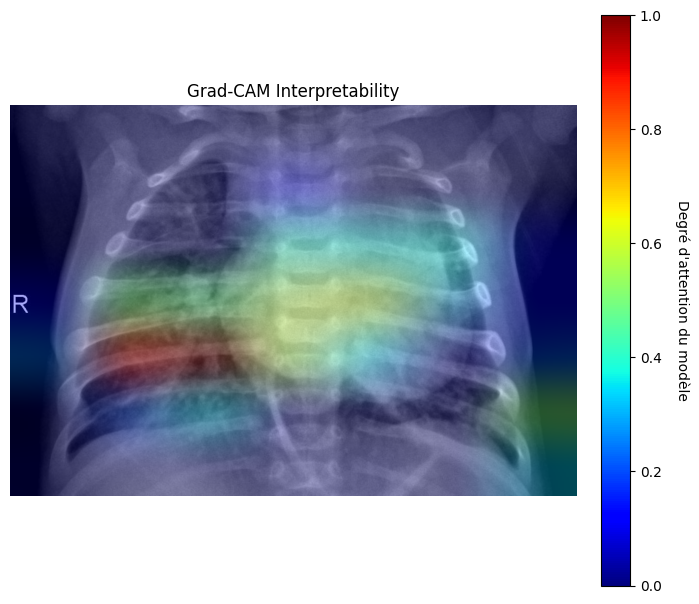

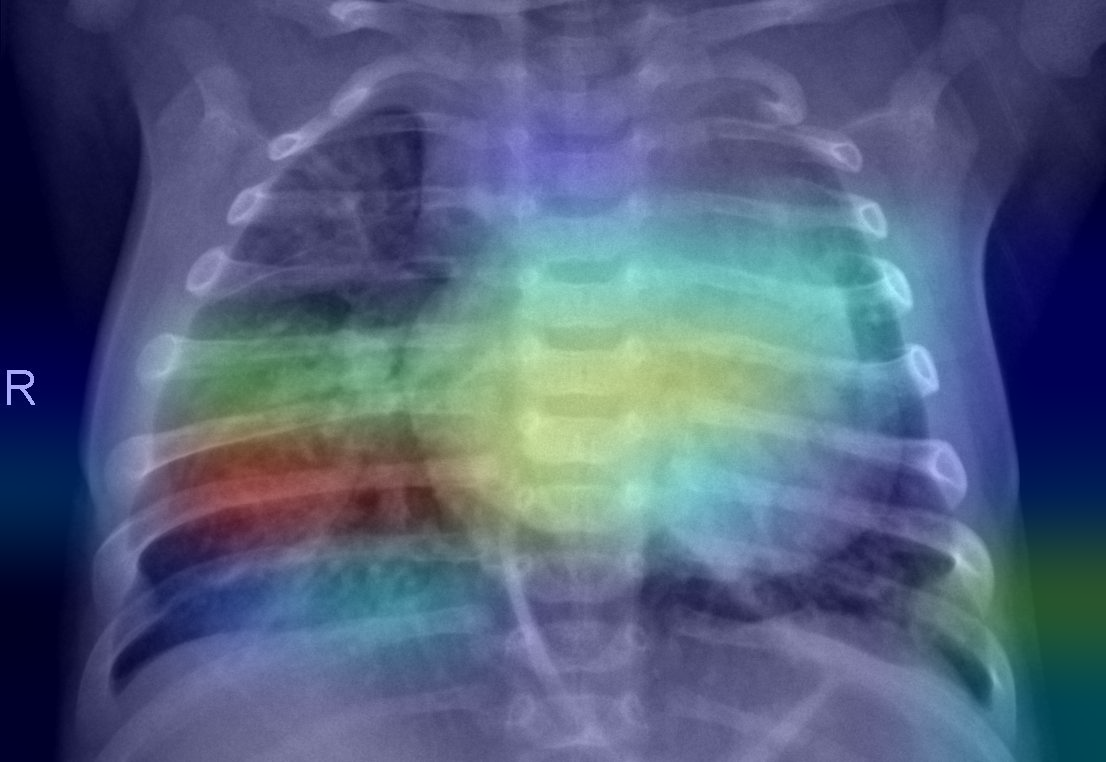

In [10]:
bacteria_path = "../data/raw/chest_Xray/test/2_BACTERIA/person100_bacteria_475.jpeg" # Assurez-vous que le chemin est correct

# Préparation de l'image
img_array = get_img_array(bacteria_path, size=(224, 224), preprocess_func=preprocess_input)

# Prédiction
preds = subtype_model.predict(img_array)[0][0]
pred_class = "VIRUS" if preds > 0.5 else "BACTERIA"
print(f"Prédiction du modèle : {pred_class} (Proba Sigmoïd: {preds:.4f})")

# Génération et affichage Grad-CAM
heatmap = make_gradcam_heatmap(img_array, subtype_model, last_conv)
display_gradcam(bacteria_path, heatmap, alpha=0.5, display=True)

### Cas 2 : Pneumonie Virale

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Prédiction du modèle : BACTERIA (Proba Sigmoïd: 0.2303)


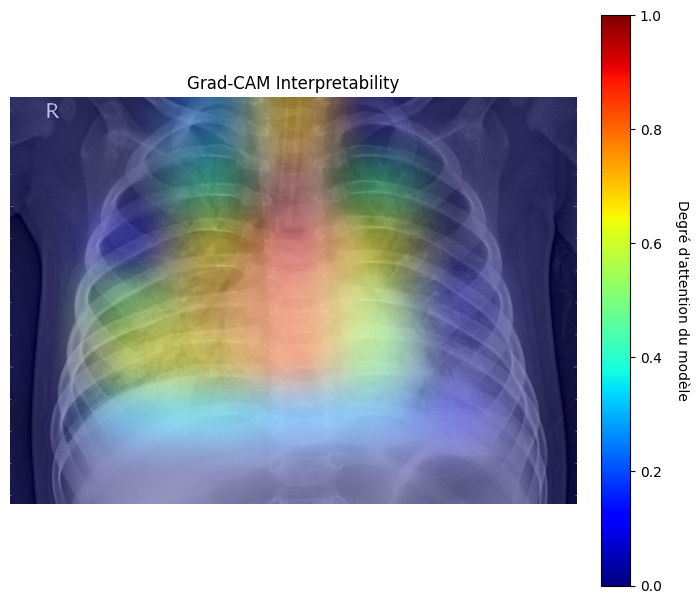

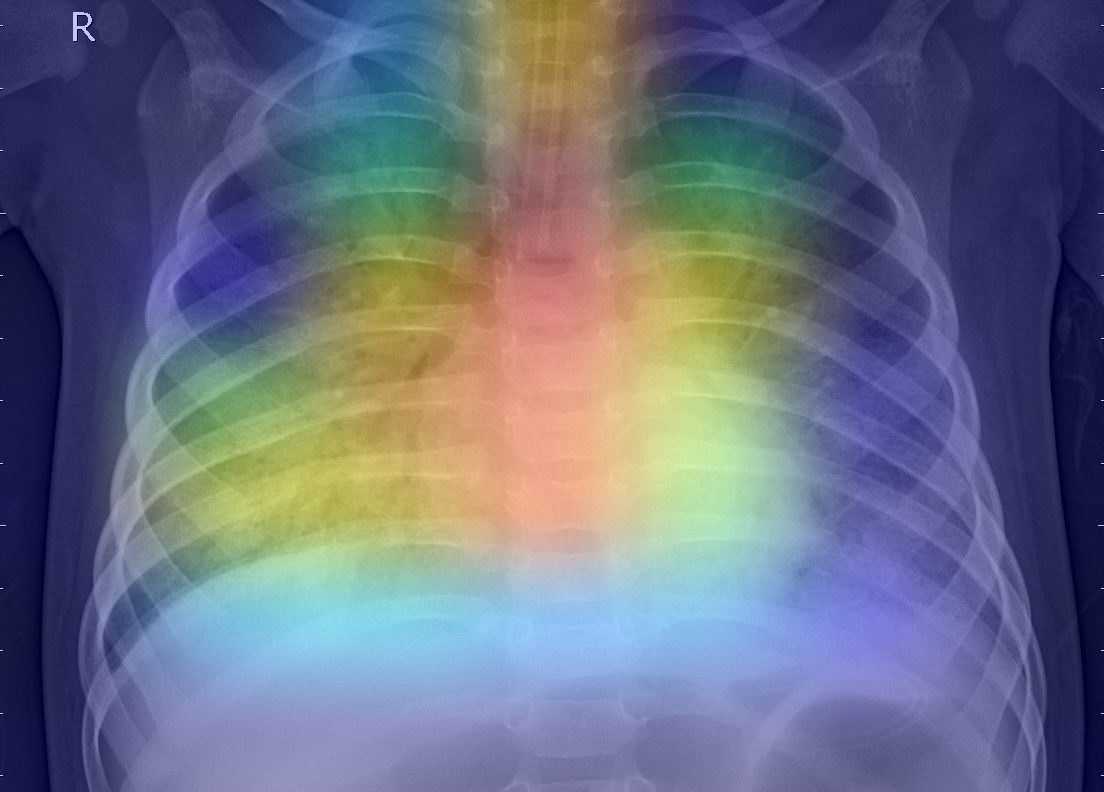

In [11]:
virus_path = "../data/raw/chest_Xray/test/3_VIRUS/person100_virus_184.jpeg" # Assurez-vous que le chemin est correct

# Préparation de l'image
img_array = get_img_array(virus_path, size=(224, 224), preprocess_func=preprocess_input)

# Prédiction
preds = subtype_model.predict(img_array)[0][0]
pred_class = "VIRUS" if preds > 0.5 else "BACTERIA"
print(f"Prédiction du modèle : {pred_class} (Proba Sigmoïd: {preds:.4f})")

# Génération et affichage Grad-CAM
heatmap = make_gradcam_heatmap(img_array, subtype_model, last_conv)
display_gradcam(virus_path, heatmap, alpha=0.5, display=True)